<a href="https://colab.research.google.com/github/ruhaan-reza/Maincraft-Internship/blob/main/TitanicAnalysis2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://raw.githubusercontent.com/ruhaan-reza/Maincraft-Internship/main/titanic%20(1).csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# EDA

**Filling age with mean**

In [4]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

dropping cabin

In [6]:
df.drop("Cabin",axis=1,inplace=True)

**filling missing values of embarked**




In [9]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


**Survival rate by Age group**

In [11]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [12]:
total_passengers = df.groupby("AgeGroup")["Survived"].count()
survivors = df.groupby("AgeGroup")["Survived"].sum()

result = pd.DataFrame({
    "Total Passengers": total_passengers,
    "Survivors": survivors
})

result["Survival Rate (%)"] = (
    result["Survivors"] / result["Total Passengers"] * 100
).round(2)

result

,Total Passengers,Survivors,Survival Rate (%)
AgeGroup,,,
Child,69,40,57.97
Teen,70,30,42.86
Young Adult,535,189,35.33
Adult,195,78,40.00
Senior,22,5,22.73


**Survival rate by Embarked**

In [15]:
embarked_survival = df.groupby("Embarked")["Survived"].sum()
total_passengers = df["Embarked"].value_counts()


result = pd.DataFrame({
    "Total Passengers": total_passengers,
    "Survivors": embarked_survival
})

result["Survival Rate (%)"] = (
    result["Survivors"] / result["Total Passengers"] * 100
).round(2)

result

,Total Passengers,Survivors,Survival Rate (%)
Embarked,,,
C,168,93,55.36
Q,77,30,38.96
S,646,219,33.90


**Survival rate by Family size(SibSp + Parch)**

In [16]:
family_size = df["SibSp"] + df["Parch"] + 1
df["FamilySize"] = family_size

In [19]:
family_size_survival = df.groupby("FamilySize")["Survived"].sum()
total_passengers = df["FamilySize"].value_counts()


result_family = pd.DataFrame({
    "Total Passengers": total_passengers,
    "Survivors": family_size_survival
})

result_family["Survival Rate (%)"] = (
    result_family["Survivors"] / result_family["Total Passengers"] * 100).round(2)

result_family = result_family.sort_index()
result_family

,Total Passengers,Survivors,Survival Rate (%)
FamilySize,,,
1,537,163,30.35
2,161,89,55.28
3,102,59,57.84
4,29,21,72.41
5,15,3,20.00
6,22,3,13.64
7,12,4,33.33
8,6,0,0.00
11,7,0,0.00


# Visualization

**Age Distribution**

<Axes: xlabel='AgeGroup', ylabel='Count'>

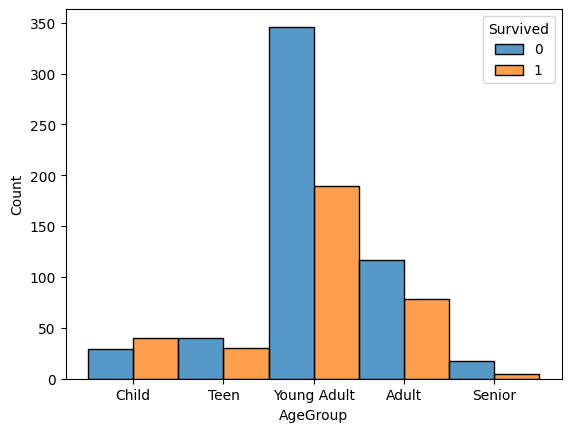

In [25]:
sns.histplot(data=df,x='AgeGroup',hue='Survived',multiple='dodge')

**Heatmap of Correlations**

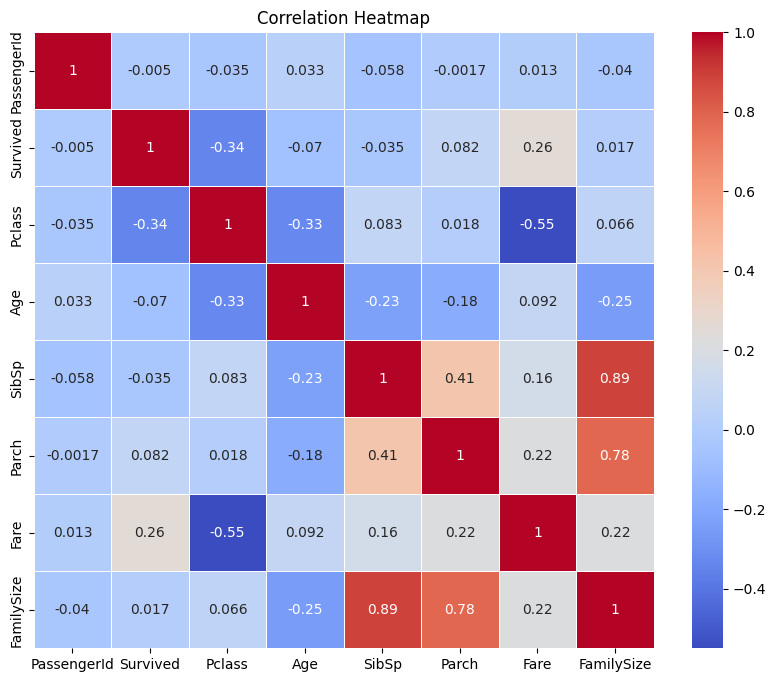

In [26]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Survival by family size**

In [27]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

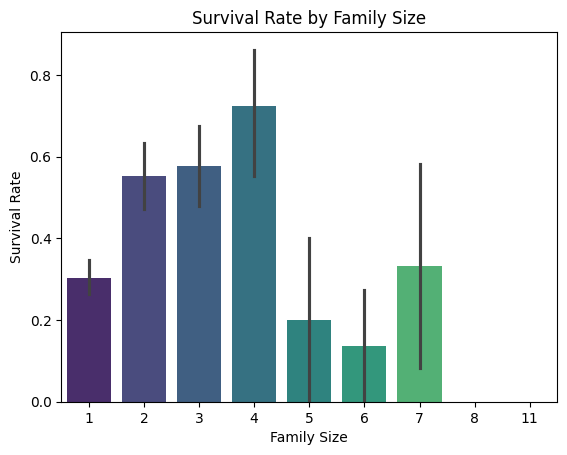

In [31]:
sns.barplot(data=df,x='FamilySize',y='Survived',palette='viridis')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Family Size')
plt.show()